# Grey-box re-identification for PolarQuest

This notebook rebuilds the vehicle identification around quantities that are actually observable and useful to the MPC.

The recommended reduced model is:

\[
\dot\kappa = \frac{a_1\delta_{cmd}+a_3\delta_{cmd}^3-\kappa}{\tau_\kappa},\qquad
\dot\psi=v\kappa
\]

and, only when supported by held-out validation data,

\[
\beta=b_0+b_1\kappa+b_3\kappa^3,\qquad
\dot x=v\cos(\psi+\beta),\quad
\dot y=v\sin(\psi+\beta).
\]

This avoids the non-identifiable pairs `L_eff`/`k_del` and `tau_acc`/`tau_v`. It also prevents sideslip coefficients from compensating unrelated model errors.

## Outputs

The notebook produces:

- a data-quality report;
- a single first-order longitudinal model;
- static and dynamic curvature-model comparisons;
- a held-out sideslip test;
- 1 s and 2 s short-horizon prediction comparisons against the ordinary kinematic bicycle;
- `greybox_reduced_model.yaml`;
- `greybox_legacy_approx.yaml` for a temporary test with the current controller structure;
- `greybox_identification_report.json`.

The existing CSV files are sufficient for an exploratory command-to-curvature model. They do **not** contain measured steering-joint angles, so a final actuator/vehicle decomposition requires new data collection. The final section gives the exact procedure.

## 1. Configuration

In [1]:
from pathlib import Path
import json
import math
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.optimize import least_squares
from scipy.signal import savgol_filter

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)

# On ChatGPT the uploaded files are under /mnt/data. On your machine the
# fallback is the notebook directory. You may also export GREYBOX_DATA_DIR.
DATA_DIR = Path(
    os.environ.get(
        "GREYBOX_DATA_DIR",
        "/mnt/data" if Path("/mnt/data").exists() else ".",
    )
)

# The resolver accepts the original names and ChatGPT duplicate suffixes.
SPEED_CSV_CANDIDATES = [
    "speed_only_01.csv",
    "speed_only_01(1).csv",
]
STEER_CSV_CANDIDATES = [
    "speed_steer_01.csv",
    "speed_steer_01(1).csv",
]

# The old combined CSV stores `v` as world-frame vx. A richer CSV created by
# extract_greybox_bag.py should contain vx_world and vy_world explicitly.
LEGACY_V_COLUMN_FRAME = "world_x"  # alternatives: "body_longitudinal"

SMOOTHING_SECONDS = 0.30
BLOCK_SECONDS = 10.0
MIN_FORWARD_SPEED = 1.0
MAX_STEERING_DEG = 35.0
WHEELBASE_M = 1.75
MAX_DELAY_SECONDS = 0.25

# A more complex model is selected only if it improves validation RMSE by more
# than this margin relative to a simpler candidate.
COMPLEXITY_IMPROVEMENT_REQUIRED = 0.02
SIDESLIP_IMPROVEMENT_REQUIRED = 0.10

OUTPUT_DIR = Path("greybox_identification_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATA_DIR: /home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/data
OUTPUT_DIR: /home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/system_identification_v2/greybox_identification_output


## 2. Load the existing CSV files

In [2]:
def resolve_candidate(directory: Path, candidates):
    for name in candidates:
        path = directory / name
        if path.exists():
            return path
    for name in candidates:
        stem = Path(name).stem.split("(")[0]
        matches = sorted(directory.glob(f"{stem}*.csv"))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"None of {candidates} was found in {directory.resolve()}"
    )


speed_path = resolve_candidate(DATA_DIR, SPEED_CSV_CANDIDATES)
steer_path = resolve_candidate(DATA_DIR, STEER_CSV_CANDIDATES)

speed_raw = pd.read_csv(speed_path)
steer_raw = pd.read_csv(steer_path)

print("Speed data:", speed_path, speed_raw.shape)
print("Steering data:", steer_path, steer_raw.shape)
print("Speed columns:", list(speed_raw.columns))
print("Steering columns:", list(steer_raw.columns))

display(speed_raw.head())
display(steer_raw.head())

Speed data: /home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/data/speed_only_01.csv (14346, 7)
Steering data: /home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/data/speed_steer_01.csv (44461, 7)
Speed columns: ['t', 'x', 'y', 'yaw', 'v', 'steering_angle', 'speed']
Steering columns: ['t', 'x', 'y', 'yaw', 'v', 'steering_angle', 'speed']


,t,x,y,yaw,v,steering_angle,speed
0,19.972,-0.009990,0.000007,-0.000004,0.064795,0.0,0.73306
1,19.992,-0.008584,0.000007,-0.000004,0.073143,0.0,0.73306
2,20.012,-0.007093,0.000007,-0.000004,0.081446,0.0,0.73306
3,20.032,-0.005378,0.000007,-0.000004,0.089629,0.0,0.73306
4,20.052,-0.003524,0.000007,-0.000004,0.097738,0.0,0.73306


,t,x,y,yaw,v,steering_angle,speed
0,18.506,0.000918,4.955464e-06,-0.000502,0.158819,-0.318532,1.459548
1,18.526,0.004308,2.814075e-06,-0.000692,0.175322,-0.318532,1.459548
2,18.546,0.007867,2.107469e-07,-0.000902,0.191727,-0.318532,1.459548
3,18.566,0.011924,-4.257296e-06,-0.001177,0.207831,-0.318532,1.459548
4,18.586,0.016198,-9.988188e-06,-0.001485,0.223797,-0.318532,1.459548


## 3. Preprocessing

Continuous measurements are smoothed and differentiated with a Savitzky–Golay filter. Commands already present in a combined sampled CSV are treated as zero-order-held samples and are **not** linearly interpolated.

The legacy files contain `v`, which is world-frame \(v_x\). Body longitudinal speed is reconstructed as

\[
v_b=v_x^w\cos\psi+v_y^w\sin\psi.
\]

In [3]:
def odd_window(seconds: float, dt: float, sample_count: int, polyorder: int = 3) -> int:
    value = max(polyorder + 2, int(round(seconds / dt)))
    if value % 2 == 0:
        value += 1
    largest_odd = sample_count if sample_count % 2 else sample_count - 1
    return min(value, largest_odd)


def wrap_array(angle):
    angle = np.asarray(angle, dtype=float)
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def first_existing(df: pd.DataFrame, names):
    for name in names:
        if name in df.columns:
            return name
    return None


def prepare_dataset(raw: pd.DataFrame, legacy_v_frame="world_x"):
    required = {"t", "x", "y", "yaw"}
    missing = required.difference(raw.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = (
        raw.copy()
        .sort_values("t")
        .drop_duplicates("t")
        .reset_index(drop=True)
    )

    t = df["t"].to_numpy(float)
    dt = float(np.median(np.diff(t)))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid or non-monotonic timestamps")

    window = odd_window(
        SMOOTHING_SECONDS,
        dt,
        len(df),
    )

    yaw = np.unwrap(df["yaw"].to_numpy(float))
    x = df["x"].to_numpy(float)
    y = df["y"].to_numpy(float)

    x_smooth = savgol_filter(x, window, 3)
    y_smooth = savgol_filter(y, window, 3)
    yaw_smooth = savgol_filter(yaw, window, 3)

    vx_name = first_existing(
        df,
        ["vx_world", "twist_vx_world"],
    )
    vy_name = first_existing(
        df,
        ["vy_world", "twist_vy_world"],
    )
    yaw_rate_name = first_existing(
        df,
        ["yaw_rate", "wz", "twist_wz"],
    )

    if vx_name:
        vx_world = df[vx_name].to_numpy(float)
    elif "v" in df.columns and legacy_v_frame == "world_x":
        vx_world = df["v"].to_numpy(float)
    elif "v" in df.columns and legacy_v_frame == "body_longitudinal":
        body = df["v"].to_numpy(float)
        vx_world = body * np.cos(yaw_smooth)
    else:
        vx_world = savgol_filter(
            x,
            window,
            3,
            deriv=1,
            delta=dt,
        )

    if vy_name:
        vy_world = df[vy_name].to_numpy(float)
    elif "v" in df.columns and legacy_v_frame == "body_longitudinal":
        body = df["v"].to_numpy(float)
        vy_world = body * np.sin(yaw_smooth)
    else:
        vy_world = savgol_filter(
            y,
            window,
            3,
            deriv=1,
            delta=dt,
        )

    if yaw_rate_name:
        yaw_rate = df[yaw_rate_name].to_numpy(float)
    else:
        yaw_rate = savgol_filter(
            yaw,
            window,
            3,
            deriv=1,
            delta=dt,
        )

    speed_cmd_name = first_existing(
        df,
        ["speed_cmd", "speed"],
    )
    steering_cmd_name = first_existing(
        df,
        ["steering_cmd", "steering_angle"],
    )
    steering_measured_name = first_existing(
        df,
        [
            "steering_measured",
            "center_steering",
            "steering_center",
        ],
    )

    if speed_cmd_name is None or steering_cmd_name is None:
        raise ValueError(
            "Could not find speed and steering command columns"
        )

    body_speed = (
        vx_world * np.cos(yaw_smooth)
        + vy_world * np.sin(yaw_smooth)
    )
    course = np.unwrap(
        np.arctan2(vy_world, vx_world)
    )
    beta = wrap_array(course - yaw_smooth)

    out = pd.DataFrame({
        "t": t,
        "x": x,
        "y": y,
        "yaw": yaw_smooth,
        "vx_world": vx_world,
        "vy_world": vy_world,
        "v_body": body_speed,
        "yaw_rate": yaw_rate,
        "speed_cmd": df[speed_cmd_name].to_numpy(float),
        "steering_cmd": df[steering_cmd_name].to_numpy(float),
        "course": course,
        "beta_measured": beta,
    })

    if steering_measured_name:
        out["steering_measured"] = (
            df[steering_measured_name].to_numpy(float)
        )

    metadata = {
        "dt": dt,
        "sample_rate_hz": 1.0 / dt,
        "smoothing_window": window,
    }

    return out, metadata


speed_df, speed_meta = prepare_dataset(
    speed_raw,
    LEGACY_V_COLUMN_FRAME,
)
steer_df, steer_meta = prepare_dataset(
    steer_raw,
    LEGACY_V_COLUMN_FRAME,
)

print(
    "Speed sample rate:",
    speed_meta["sample_rate_hz"],
    "Hz",
)
print(
    "Steering sample rate:",
    steer_meta["sample_rate_hz"],
    "Hz",
)
print(
    "Measured steering available:",
    "steering_measured" in steer_df.columns,
)


Speed sample rate: 50.000000000001066 Hz
Steering sample rate: 50.000000000045475 Hz
Measured steering available: False


## 4. Data-quality audit

,dataset,samples,duration_s,sample_rate_hz,body_speed_min,body_speed_max,steering_min_deg,steering_max_deg,forward_samples_over_threshold
0,speed,14346,286.9,50.0,-4.378189,7.044211,0.000000,0.000000,5599
1,steering,44461,889.2,50.0,-6.906655,5.641425,-28.714556,36.863586,16823


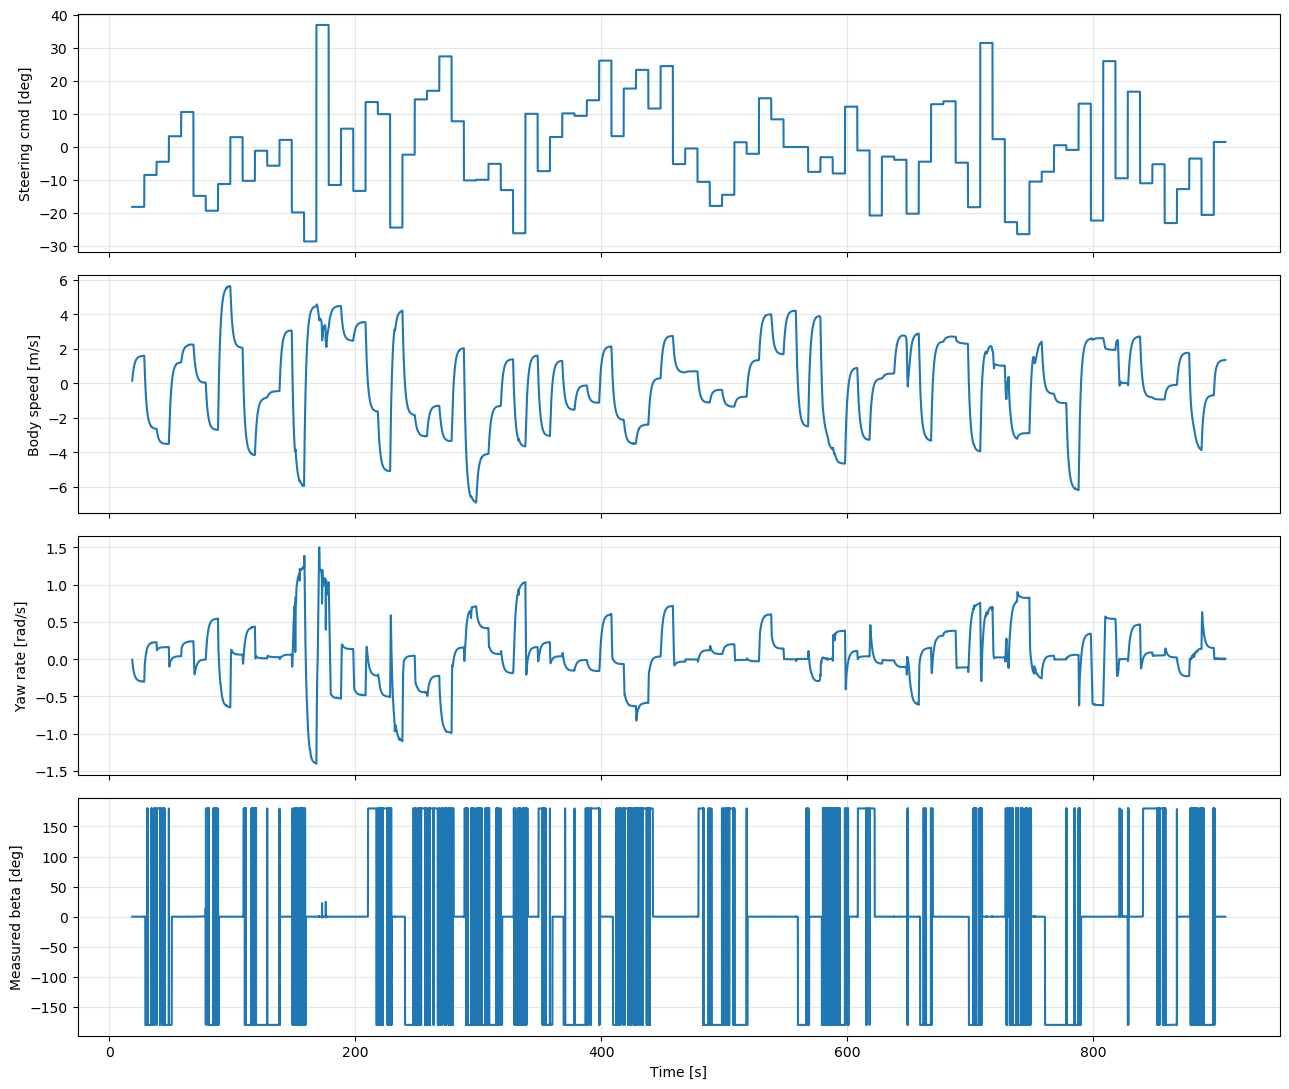

In [4]:
def audit(df: pd.DataFrame, name: str, metadata):
    dt = float(metadata["dt"])
    report = {
        "dataset": name,
        "samples": len(df),
        "duration_s": float(df.t.iloc[-1] - df.t.iloc[0]),
        "sample_rate_hz": float(1.0 / dt),
        "body_speed_min": float(df.v_body.min()),
        "body_speed_max": float(df.v_body.max()),
        "steering_min_deg": float(np.degrees(df.steering_cmd.min())),
        "steering_max_deg": float(np.degrees(df.steering_cmd.max())),
        "forward_samples_over_threshold": int((df.v_body > MIN_FORWARD_SPEED).sum()),
    }
    return report


audit_table = pd.DataFrame([
    audit(speed_df, "speed", speed_meta),
    audit(steer_df, "steering", steer_meta),
])
display(audit_table)

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
axes[0].plot(steer_df.t, np.degrees(steer_df.steering_cmd))
axes[0].set_ylabel("Steering cmd [deg]")
axes[1].plot(steer_df.t, steer_df.v_body)
axes[1].set_ylabel("Body speed [m/s]")
axes[2].plot(steer_df.t, steer_df.yaw_rate)
axes[2].set_ylabel("Yaw rate [rad/s]")
axes[3].plot(steer_df.t, np.degrees(steer_df.beta_measured))
axes[3].set_ylabel("Measured beta [deg]")
axes[3].set_xlabel("Time [s]")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Train, validation and test blocks

The existing recording is divided into alternating contiguous blocks. This is acceptable for exploratory work, but a final paper result must use independent recordings for identification, controller tuning and final evaluation.

In [5]:
def add_split(
    df: pd.DataFrame,
    block_seconds=10.0,
) -> pd.DataFrame:
    out = df.copy()

    block = np.floor(
        (
            out["t"].to_numpy()
            - float(out["t"].iloc[0])
        )
        / block_seconds
    ).astype(int)

    labels = np.array([
        "train",
        "validation",
        "test",
    ])

    out["split"] = labels[block % 3]
    out["block"] = block

    return out


speed_df = add_split(
    speed_df,
    BLOCK_SECONDS,
)

steer_df = add_split(
    steer_df,
    BLOCK_SECONDS,
)

# Avoid pandas named-aggregation syntax because the ROS Noetic
# container may contain an older pandas release.
split_samples = (
    steer_df
    .groupby("split")["t"]
    .size()
)

split_summary = pd.DataFrame({
    "samples": split_samples,
})

split_summary["duration_s"] = (
    split_summary["samples"].astype(float)
    * float(steer_meta["dt"])
)

display(split_summary)


,samples,duration_s
split,,
test,14500,290.00
train,15001,300.02
validation,14960,299.20


## 6. Identify a single longitudinal model

The old cascade `speed_cmd -> uva -> v` is replaced by one observable first-order model:

\[
\dot v=\frac{K_vu_v(t-T_v)+b_v-v}{\tau_v}.
\]

,tau_v,gain_v,bias_v,delay_steps_v,delay_s_v,train_rmse,validation_rmse,test_rmse
4,1.558030,1.008675,-0.005770,4,0.08,0.105421,0.116559,0.218980
3,1.580611,1.011419,-0.006844,3,0.06,0.102980,0.116945,0.219004
5,1.535631,1.005910,-0.004670,5,0.10,0.108617,0.117223,0.219466
2,1.603367,1.014138,-0.007892,2,0.04,0.101366,0.118391,0.219528
6,1.513416,1.003125,-0.003547,6,0.12,0.112488,0.118898,0.220474
1,1.626294,1.016831,-0.008910,1,0.02,0.100635,0.120873,0.220531
7,1.491389,1.000324,-0.002404,7,0.14,0.116955,0.121520,0.222014
0,1.649379,1.019496,-0.009896,0,0.00,0.100795,0.124319,0.221989
8,1.469551,0.997509,-0.001243,8,0.16,0.121939,0.125000,0.224094
9,1.447903,0.994683,-0.000067,9,0.18,0.127364,0.129241,0.226722


Selected speed model:


{'tau_v': 1.5580303592291165,
 'gain_v': 1.0086749755209905,
 'bias_v': -0.005769607411966023,
 'delay_steps_v': 4,
 'delay_s_v': 0.0799999999999983,
 'train_rmse': 0.10542064775280068,
 'validation_rmse': 0.11655877675602137,
 'test_rmse': 0.21897958482348973}

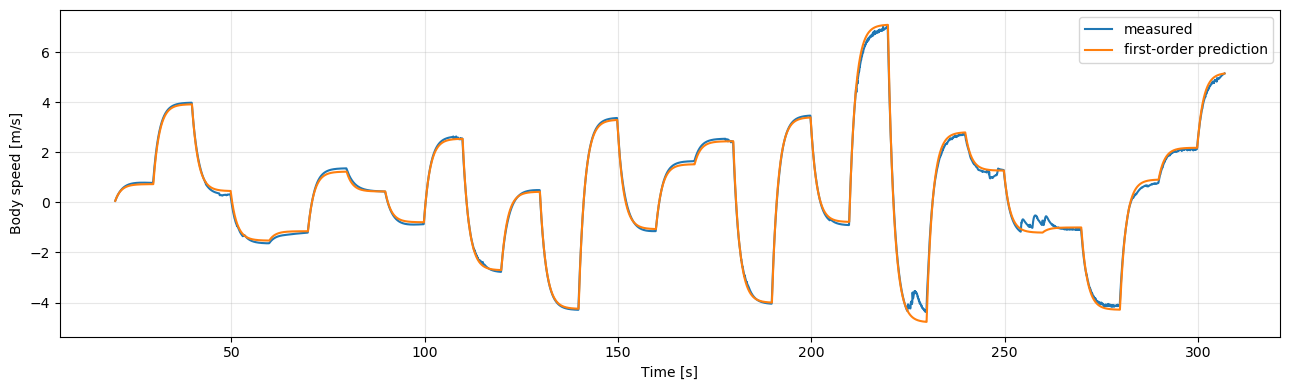

In [6]:
def delay_signal(values, delay_steps):
    values = np.asarray(values, dtype=float)
    if delay_steps <= 0:
        return values.copy()
    return np.concatenate([
        np.full(delay_steps, values[0], dtype=float),
        values[:-delay_steps],
    ])


def simulate_first_order(command, dt, tau, gain=1.0, bias=0.0, delay_steps=0, initial=0.0):
    command_delayed = delay_signal(command, delay_steps)
    result = np.empty_like(command_delayed)
    result[0] = float(initial)
    alpha = math.exp(-dt / max(float(tau), 1e-6))
    target = gain * command_delayed + bias
    for k in range(1, len(result)):
        result[k] = alpha * result[k - 1] + (1.0 - alpha) * target[k - 1]
    return result


def rmse(a, b, mask):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    return float(np.sqrt(np.mean((a[mask] - b[mask]) ** 2)))


def fit_speed_model(df: pd.DataFrame, metadata):
    t = df.t.to_numpy(float)
    u = df.speed_cmd.to_numpy(float)
    measured = df.v_body.to_numpy(float)
    dt = float(metadata["dt"])
    finite = np.isfinite(u) & np.isfinite(measured)
    train = finite & (df.split.to_numpy() == "train")
    validation = finite & (df.split.to_numpy() == "validation")
    test = finite & (df.split.to_numpy() == "test")
    scale = max(float(np.std(measured[train])), 0.1)
    max_delay = int(round(MAX_DELAY_SECONDS / dt))
    candidates = []

    for delay_steps in range(max_delay + 1):
        def residual(parameters):
            tau, gain, bias = parameters
            predicted = simulate_first_order(
                u, dt, tau, gain, bias, delay_steps, measured[0]
            )
            return (predicted[train] - measured[train]) / scale

        result = least_squares(
            residual,
            x0=np.array([0.8, 1.0, 0.0]),
            bounds=(
                np.array([0.02, 0.5, -1.0]),
                np.array([5.0, 1.5, 1.0]),
            ),
            loss="soft_l1",
            max_nfev=2000,
        )
        tau, gain, bias = result.x
        predicted = simulate_first_order(
            u, dt, tau, gain, bias, delay_steps, measured[0]
        )
        candidates.append({
            "tau_v": float(tau),
            "gain_v": float(gain),
            "bias_v": float(bias),
            "delay_steps_v": int(delay_steps),
            "delay_s_v": float(delay_steps * dt),
            "train_rmse": rmse(predicted, measured, train),
            "validation_rmse": rmse(predicted, measured, validation),
            "test_rmse": rmse(predicted, measured, test),
            "predicted": predicted,
        })

    return min(candidates, key=lambda item: item["validation_rmse"]), candidates


speed_fit, speed_candidates = fit_speed_model(speed_df, speed_meta)
display(pd.DataFrame([{k: v for k, v in c.items() if k != "predicted"}
                      for c in speed_candidates]).sort_values("validation_rmse").head(10))
print("Selected speed model:")
display({k: v for k, v in speed_fit.items() if k != "predicted"})

plt.figure(figsize=(13, 4))
plt.plot(speed_df.t, speed_df.v_body, label="measured")
plt.plot(speed_df.t, speed_fit["predicted"], label="first-order prediction")
plt.xlabel("Time [s]")
plt.ylabel("Body speed [m/s]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Identify the effective curvature dynamics

The observable target is curvature, not an artificial separation between steering gain and effective wheelbase:

\[
\kappa_{meas}=\frac{\dot\psi}{v_b}.
\]

Four candidates are compared:

1. static linear;
2. static cubic;
3. first-order dynamic linear;
4. first-order dynamic cubic.

The fitting loss is applied to yaw rate, \(\dot\psi=v_b\kappa\), to avoid excessive noise from division at low speeds.

In [7]:
def simulate_curvature(command, dt, tau, a1, a3, delay_steps, initial_curvature=0.0):
    command_delayed = delay_signal(command, delay_steps)
    target = a1 * command_delayed + a3 * command_delayed ** 3
    if tau <= 0.0:
        return target
    result = np.empty_like(target)
    result[0] = float(initial_curvature)
    alpha = math.exp(-dt / max(float(tau), 1e-6))
    for k in range(1, len(result)):
        result[k] = alpha * result[k - 1] + (1.0 - alpha) * target[k - 1]
    return result


def lateral_masks(df: pd.DataFrame):
    v = df.v_body.to_numpy(float)
    delta = df.steering_cmd.to_numpy(float)
    yaw_rate = df.yaw_rate.to_numpy(float)
    base = (
        np.isfinite(v)
        & np.isfinite(delta)
        & np.isfinite(yaw_rate)
        & (v > MIN_FORWARD_SPEED)
        & (np.abs(delta) <= np.deg2rad(MAX_STEERING_DEG))
        & (np.abs(yaw_rate) < 3.0)
    )
    split = df.split.to_numpy()
    return (
        base & (split == "train"),
        base & (split == "validation"),
        base & (split == "test"),
        base,
    )


def fit_curvature_candidates(df: pd.DataFrame, metadata):
    delta = df.steering_cmd.to_numpy(float)
    v = df.v_body.to_numpy(float)
    yaw_rate = df.yaw_rate.to_numpy(float)
    dt = float(metadata["dt"])
    train, validation, test, base = lateral_masks(df)
    scale = max(float(np.std(yaw_rate[train])), 0.05)
    max_delay = int(round(MAX_DELAY_SECONDS / dt))
    initial_index = int(np.flatnonzero(base)[0])
    initial_kappa = yaw_rate[initial_index] / v[initial_index]
    candidates = []

    specifications = [
        ("static_linear", False, False),
        ("static_cubic", False, True),
        ("dynamic_linear", True, False),
        ("dynamic_cubic", True, True),
    ]

    for name, dynamic, cubic in specifications:
        for delay_steps in range(max_delay + 1):
            def residual(parameters):
                cursor = 0
                tau = float(parameters[cursor]) if dynamic else 0.0
                cursor += int(dynamic)
                a1 = float(parameters[cursor])
                cursor += 1
                a3 = float(parameters[cursor]) if cubic else 0.0
                kappa = simulate_curvature(
                    delta, dt, tau, a1, a3, delay_steps, initial_kappa
                )
                predicted_yaw_rate = v * kappa
                return (predicted_yaw_rate[train] - yaw_rate[train]) / scale

            x0 = []
            lower = []
            upper = []
            if dynamic:
                x0.append(0.4); lower.append(0.02); upper.append(3.0)
            x0.append(1.0 / WHEELBASE_M); lower.append(0.05); upper.append(2.0)
            if cubic:
                x0.append(0.0); lower.append(-5.0); upper.append(5.0)

            result = least_squares(
                residual,
                x0=np.asarray(x0),
                bounds=(np.asarray(lower), np.asarray(upper)),
                loss="soft_l1",
                max_nfev=2000,
            )

            cursor = 0
            tau = float(result.x[cursor]) if dynamic else 0.0
            cursor += int(dynamic)
            a1 = float(result.x[cursor]); cursor += 1
            a3 = float(result.x[cursor]) if cubic else 0.0
            kappa = simulate_curvature(
                delta, dt, tau, a1, a3, delay_steps, initial_kappa
            )
            predicted_yaw_rate = v * kappa
            candidate = {
                "model": name,
                "dynamic": dynamic,
                "cubic": cubic,
                "tau_kappa": tau,
                "a1": a1,
                "a3": a3,
                "delay_steps": int(delay_steps),
                "delay_s": float(delay_steps * dt),
                "parameter_count": int(dynamic) + 1 + int(cubic) + int(delay_steps > 0),
                "train_yaw_rate_rmse": rmse(predicted_yaw_rate, yaw_rate, train),
                "validation_yaw_rate_rmse": rmse(predicted_yaw_rate, yaw_rate, validation),
                "test_yaw_rate_rmse": rmse(predicted_yaw_rate, yaw_rate, test),
                "kappa_predicted": kappa,
                "yaw_rate_predicted": predicted_yaw_rate,
            }
            candidates.append(candidate)

    return candidates


curvature_candidates = fit_curvature_candidates(steer_df, steer_meta)
curvature_table = pd.DataFrame([
    {k: v for k, v in c.items() if not isinstance(v, np.ndarray)}
    for c in curvature_candidates
]).sort_values(["validation_yaw_rate_rmse", "parameter_count"])

display(curvature_table.head(15))

,model,dynamic,cubic,tau_kappa,a1,a3,delay_steps,delay_s,parameter_count,train_yaw_rate_rmse,validation_yaw_rate_rmse,test_yaw_rate_rmse
42,dynamic_cubic,True,True,0.597489,0.592336,0.056289,0,0.00,3,0.027297,0.046260,0.030376
43,dynamic_cubic,True,True,0.570954,0.592575,0.049274,1,0.02,4,0.026846,0.046778,0.030174
28,dynamic_linear,True,False,0.601225,0.600723,0.000000,0,0.00,2,0.027524,0.047146,0.031854
44,dynamic_cubic,True,True,0.545644,0.592818,0.042459,2,0.04,4,0.026611,0.047336,0.030092
29,dynamic_linear,True,False,0.574110,0.599915,0.000000,1,0.02,3,0.027017,0.047552,0.031547
45,dynamic_cubic,True,True,0.521806,0.593061,0.035913,3,0.06,4,0.026605,0.047897,0.030131
30,dynamic_linear,True,False,0.548234,0.599140,0.000000,2,0.04,3,0.026734,0.048003,0.031339
46,dynamic_cubic,True,True,0.499684,0.593297,0.029734,4,0.08,4,0.026823,0.048420,0.030289
31,dynamic_linear,True,False,0.523859,0.598405,0.000000,3,0.06,3,0.026687,0.048462,0.031235
47,dynamic_cubic,True,True,0.479444,0.593516,0.024068,5,0.10,4,0.027238,0.048872,0.030559


## 8. Select the simplest model that is materially competitive

Selected curvature model:


{'model': 'dynamic_linear',
 'dynamic': True,
 'cubic': False,
 'tau_kappa': 0.6012253028518952,
 'a1': 0.6007225376271349,
 'a3': 0.0,
 'delay_steps': 0,
 'delay_s': 0.0,
 'parameter_count': 2,
 'train_yaw_rate_rmse': 0.027523872790396274,
 'validation_yaw_rate_rmse': 0.04714616129794715,
 'test_yaw_rate_rmse': 0.03185435381663606}

,model,train_rmse,validation_rmse,test_rmse
0,kinematic bicycle,0.127270,0.138846,0.097142
1,dynamic_linear,0.027524,0.047146,0.031854


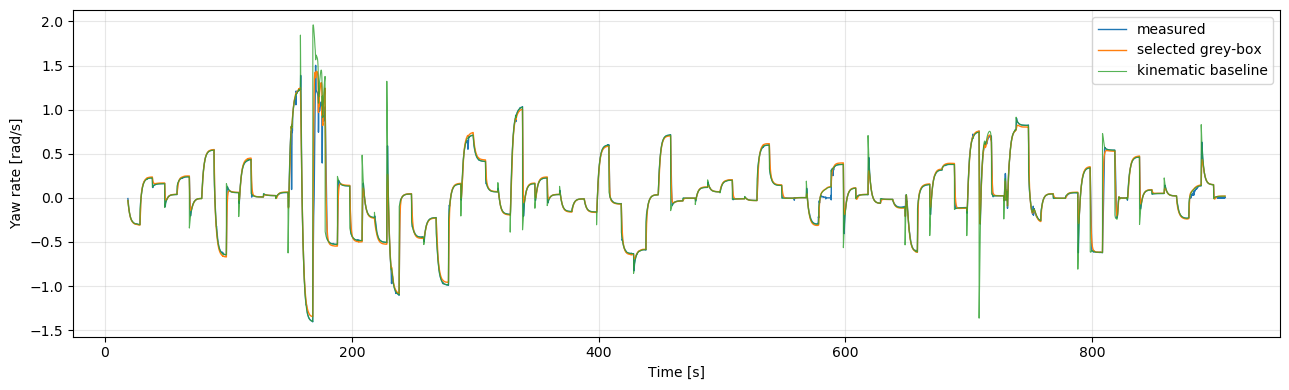

In [8]:
def model_complexity_rank(name):
    return {
        "static_linear": 0,
        "static_cubic": 1,
        "dynamic_linear": 2,
        "dynamic_cubic": 3,
    }[name]


best_validation = min(c["validation_yaw_rate_rmse"] for c in curvature_candidates)
eligible = [
    c for c in curvature_candidates
    if c["validation_yaw_rate_rmse"] <= best_validation * (1.0 + COMPLEXITY_IMPROVEMENT_REQUIRED)
]
selected_curvature = min(
    eligible,
    key=lambda c: (model_complexity_rank(c["model"]), c["parameter_count"], c["validation_yaw_rate_rmse"]),
)

print("Selected curvature model:")
display({k: v for k, v in selected_curvature.items() if not isinstance(v, np.ndarray)})

# Ordinary kinematic bicycle baseline using command as instantaneous steering.
kinematic_yaw_rate = (
    steer_df.v_body.to_numpy(float)
    * np.tan(steer_df.steering_cmd.to_numpy(float))
    / WHEELBASE_M
)
train_mask, validation_mask, test_mask, base_mask = lateral_masks(steer_df)
comparison = pd.DataFrame([
    {
        "model": "kinematic bicycle",
        "train_rmse": rmse(kinematic_yaw_rate, steer_df.yaw_rate, train_mask),
        "validation_rmse": rmse(kinematic_yaw_rate, steer_df.yaw_rate, validation_mask),
        "test_rmse": rmse(kinematic_yaw_rate, steer_df.yaw_rate, test_mask),
    },
    {
        "model": selected_curvature["model"],
        "train_rmse": selected_curvature["train_yaw_rate_rmse"],
        "validation_rmse": selected_curvature["validation_yaw_rate_rmse"],
        "test_rmse": selected_curvature["test_yaw_rate_rmse"],
    },
])
display(comparison)

plt.figure(figsize=(13, 4))
plt.plot(steer_df.t, steer_df.yaw_rate, label="measured", linewidth=1)
plt.plot(steer_df.t, selected_curvature["yaw_rate_predicted"], label="selected grey-box", linewidth=1)
plt.plot(steer_df.t, kinematic_yaw_rate, label="kinematic baseline", linewidth=0.8, alpha=0.8)
plt.xlabel("Time [s]")
plt.ylabel("Yaw rate [rad/s]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Test whether sideslip is supported

Sideslip is added only if it reduces held-out validation RMSE by at least 10%. A bias or polynomial that reaches a bound is not accepted automatically.

Sideslip result:


{'b0': -3.97792615342939e-05,
 'b1': 0.00039211792966741606,
 'b3': 0.0044888643602253595,
 'zero_validation_rmse': 0.0004756186100993859,
 'fitted_validation_rmse': 0.0004722677486493545,
 'zero_test_rmse': 0.0003503137331154867,
 'fitted_test_rmse': 0.0003485681307845695,
 'validation_improvement': 0.0070452698420089685,
 'enabled': False}

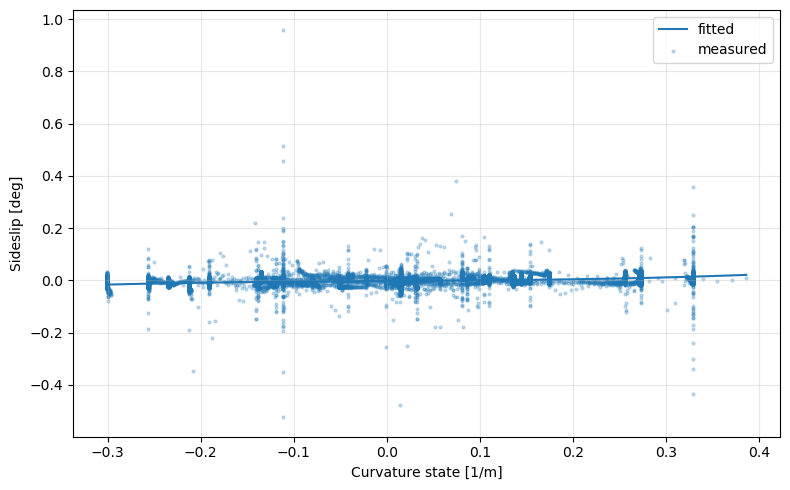

In [9]:
def fit_sideslip(df: pd.DataFrame, curvature_state: np.ndarray):
    beta = df.beta_measured.to_numpy(float)
    v = df.v_body.to_numpy(float)
    split = df.split.to_numpy()
    base = (
        np.isfinite(beta)
        & np.isfinite(curvature_state)
        & (v > MIN_FORWARD_SPEED)
        & (np.abs(beta) < np.deg2rad(20.0))
    )
    train = base & (split == "train")
    validation = base & (split == "validation")
    test = base & (split == "test")
    scale = max(float(np.std(beta[train])), np.deg2rad(0.1))

    def residual(parameters):
        b0, b1, b3 = parameters
        prediction = b0 + b1 * curvature_state + b3 * curvature_state ** 3
        return (prediction[train] - beta[train]) / scale

    result = least_squares(
        residual,
        x0=np.zeros(3),
        bounds=(
            np.array([-0.2, -2.0, -10.0]),
            np.array([0.2, 2.0, 10.0]),
        ),
        loss="soft_l1",
        max_nfev=2000,
    )
    b0, b1, b3 = result.x
    predicted = b0 + b1 * curvature_state + b3 * curvature_state ** 3
    zero = np.zeros_like(beta)

    output = {
        "b0": float(b0),
        "b1": float(b1),
        "b3": float(b3),
        "zero_validation_rmse": rmse(zero, beta, validation),
        "fitted_validation_rmse": rmse(predicted, beta, validation),
        "zero_test_rmse": rmse(zero, beta, test),
        "fitted_test_rmse": rmse(predicted, beta, test),
        "predicted": predicted,
    }
    output["validation_improvement"] = (
        output["zero_validation_rmse"] - output["fitted_validation_rmse"]
    ) / max(output["zero_validation_rmse"], 1e-12)
    output["enabled"] = bool(output["validation_improvement"] >= SIDESLIP_IMPROVEMENT_REQUIRED)
    return output


sideslip_fit = fit_sideslip(steer_df, selected_curvature["kappa_predicted"])
print("Sideslip result:")
display({k: v for k, v in sideslip_fit.items() if not isinstance(v, np.ndarray)})

plt.figure(figsize=(8, 5))
plt.scatter(
    selected_curvature["kappa_predicted"][base_mask],
    np.degrees(steer_df.beta_measured.to_numpy()[base_mask]),
    s=4,
    alpha=0.25,
    label="measured",
)
order = np.argsort(selected_curvature["kappa_predicted"])
plt.plot(
    selected_curvature["kappa_predicted"][order],
    np.degrees(sideslip_fit["predicted"][order]),
    label="fitted",
)
plt.xlabel("Curvature state [1/m]")
plt.ylabel("Sideslip [deg]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Short-horizon prediction test

This is closer to the MPC use case than a single free simulation over hundreds of seconds. Each test starts from the measured pose and predicts the next 1 or 2 seconds using the measured speed sequence and command sequence.

In [10]:
def integrate_prediction(x0, y0, yaw0, speeds, curvatures, dt, betas=None):
    n = len(speeds)
    x = np.empty(n); y = np.empty(n); yaw = np.empty(n)
    x[0] = x0; y[0] = y0; yaw[0] = yaw0
    if betas is None:
        betas = np.zeros(n)
    for k in range(1, n):
        yaw[k] = yaw[k - 1] + dt * speeds[k - 1] * curvatures[k - 1]
        direction = yaw[k - 1] + betas[k - 1]
        x[k] = x[k - 1] + dt * speeds[k - 1] * math.cos(direction)
        y[k] = y[k - 1] + dt * speeds[k - 1] * math.sin(direction)
    return x, y, yaw


def horizon_evaluation(df, selected, sideslip, horizon_s, dt, stride=25):
    dt = float(dt)
    steps = int(round(horizon_s / dt)) + 1
    delta = df.steering_cmd.to_numpy(float)
    v = df.v_body.to_numpy(float)
    x_m = df.x.to_numpy(float)
    y_m = df.y.to_numpy(float)
    yaw_m = df.yaw.to_numpy(float)
    split = df.split.to_numpy()
    kappa_grey = selected["kappa_predicted"]
    beta_grey = sideslip["predicted"] if sideslip["enabled"] else np.zeros(len(df))
    kappa_kin = np.tan(delta) / WHEELBASE_M

    records = []
    for start in range(0, len(df) - steps, stride):
        stop = start + steps
        if not np.all(split[start:stop] == "test"):
            continue
        if not np.all(v[start:stop] > MIN_FORWARD_SPEED):
            continue

        kg = kappa_grey[start:stop]
        kk = kappa_kin[start:stop]
        vg = v[start:stop]
        bg = beta_grey[start:stop]

        xg, yg, yawg = integrate_prediction(
            x_m[start], y_m[start], yaw_m[start], vg, kg, dt, bg
        )
        xk, yk, yawk = integrate_prediction(
            x_m[start], y_m[start], yaw_m[start], vg, kk, dt
        )

        records.append({
            "grey_position_endpoint_error": float(np.hypot(xg[-1] - x_m[stop - 1], yg[-1] - y_m[stop - 1])),
            "kin_position_endpoint_error": float(np.hypot(xk[-1] - x_m[stop - 1], yk[-1] - y_m[stop - 1])),
            "grey_yaw_endpoint_error": float(abs(wrap_array(yawg[-1] - yaw_m[stop - 1]))),
            "kin_yaw_endpoint_error": float(abs(wrap_array(yawk[-1] - yaw_m[stop - 1]))),
        })

    table = pd.DataFrame(records)
    if table.empty:
        raise RuntimeError("No valid held-out prediction windows were found")
    return {
        "horizon_s": horizon_s,
        "windows": len(table),
        "grey_position_rmse": float(np.sqrt(np.mean(table.grey_position_endpoint_error ** 2))),
        "kin_position_rmse": float(np.sqrt(np.mean(table.kin_position_endpoint_error ** 2))),
        "grey_yaw_rmse_deg": float(np.degrees(np.sqrt(np.mean(table.grey_yaw_endpoint_error ** 2)))),
        "kin_yaw_rmse_deg": float(np.degrees(np.sqrt(np.mean(table.kin_yaw_endpoint_error ** 2)))),
    }, table


horizon_reports = []
horizon_tables = {}
for horizon in (1.0, 2.0):
    report, table = horizon_evaluation(
        steer_df,
        selected_curvature,
        sideslip_fit,
        horizon,
        steer_meta["dt"],
    )
    horizon_reports.append(report)
    horizon_tables[horizon] = table

display(pd.DataFrame(horizon_reports))

,horizon_s,windows,grey_position_rmse,kin_position_rmse,grey_yaw_rmse_deg,kin_yaw_rmse_deg
0,1.0,174,0.047782,0.034051,1.121571,3.016710
1,2.0,148,0.131361,0.057961,1.926447,3.304123


## 11. Export the reduced model and a temporary legacy approximation

In [11]:
reduced_model = {
    "model_type": "effective_curvature_first_order",
    "identification_sample_time_s": float(steer_meta["dt"]),
    "speed": {
        "tau_v": speed_fit["tau_v"],
        "gain_v": speed_fit["gain_v"],
        "bias_v": speed_fit["bias_v"],
        "delay_steps": speed_fit["delay_steps_v"],
        "delay_s": speed_fit["delay_s_v"],
    },
    "curvature": {
        "model": selected_curvature["model"],
        "tau_kappa": selected_curvature["tau_kappa"],
        "a1": selected_curvature["a1"],
        "a3": selected_curvature["a3"],
        "delay_steps": selected_curvature["delay_steps"],
        "delay_s": selected_curvature["delay_s"],
    },
    "sideslip": {
        "enabled": sideslip_fit["enabled"],
        "b0": sideslip_fit["b0"] if sideslip_fit["enabled"] else 0.0,
        "b1": sideslip_fit["b1"] if sideslip_fit["enabled"] else 0.0,
        "b3": sideslip_fit["b3"] if sideslip_fit["enabled"] else 0.0,
        "validation_improvement": sideslip_fit["validation_improvement"],
    },
}

reduced_path = OUTPUT_DIR / "greybox_reduced_model.yaml"
with reduced_path.open("w") as stream:
    yaml.safe_dump(reduced_model, stream, sort_keys=False)

# Temporary mapping to the old L_eff/k_del architecture. It preserves the
# small-angle curvature gain: k_del / L_eff ~= a1. It is not the preferred
# final implementation because the reduced curvature state is more identifiable.
legacy_approx = {
    "tau_acc": 0.05,
    "tau_str": float(selected_curvature["tau_kappa"]),
    "tau_v": float(speed_fit["tau_v"]),
    "L_eff": float(WHEELBASE_M),
    "k_del": float(selected_curvature["a1"] * WHEELBASE_M),
    "k_b1": 0.0,
    "k_b3": 0.0,
    "psi_bias": 0.0,
}
legacy_path = OUTPUT_DIR / "greybox_legacy_approx.yaml"
with legacy_path.open("w") as stream:
    yaml.safe_dump(legacy_approx, stream, sort_keys=False)

report = {
    "audit": audit_table.to_dict(orient="records"),
    "speed_model": {k: v for k, v in speed_fit.items() if k != "predicted"},
    "curvature_model": {k: v for k, v in selected_curvature.items() if not isinstance(v, np.ndarray)},
    "sideslip": {k: v for k, v in sideslip_fit.items() if not isinstance(v, np.ndarray)},
    "horizon_evaluation": horizon_reports,
    "files": {
        "speed_csv": str(speed_path),
        "steer_csv": str(steer_path),
    },
}
report_path = OUTPUT_DIR / "greybox_identification_report.json"
report_path.write_text(json.dumps(report, indent=2))

print(reduced_path.resolve())
print(legacy_path.resolve())
print(report_path.resolve())
display(reduced_model)
display(legacy_approx)

/home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/system_identification_v2/greybox_identification_output/greybox_reduced_model.yaml
/home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/system_identification_v2/greybox_identification_output/greybox_legacy_approx.yaml
/home/dev/code/polarquest/ws/src/polaris_system_id/src/analysis/system_identification_v2/greybox_identification_output/greybox_identification_report.json


{'model_type': 'effective_curvature_first_order',
 'identification_sample_time_s': 0.01999999999998181,
 'speed': {'tau_v': 1.5580303592291165,
  'gain_v': 1.0086749755209905,
  'bias_v': -0.005769607411966023,
  'delay_steps': 4,
  'delay_s': 0.0799999999999983},
 'curvature': {'model': 'dynamic_linear',
  'tau_kappa': 0.6012253028518952,
  'a1': 0.6007225376271349,
  'a3': 0.0,
  'delay_steps': 0,
  'delay_s': 0.0},
 'sideslip': {'enabled': False,
  'b0': 0.0,
  'b1': 0.0,
  'b3': 0.0,
  'validation_improvement': 0.0070452698420089685}}

{'tau_acc': 0.05,
 'tau_str': 0.6012253028518952,
 'tau_v': 1.5580303592291165,
 'L_eff': 1.75,
 'k_del': 1.051264440847486,
 'k_b1': 0.0,
 'k_b3': 0.0,
 'psi_bias': 0.0}

## 12. Preferred controller equations

Replace the old `da`, `L_eff`, `k_del`, `k_b1`, `k_b3` and `psi_bias` block with an effective-curvature state:

```python
self.kappa = self.m.Var(value=0.0, lb=-1.0, ub=1.0)

target_kappa = self.m.Intermediate(
    a1 * self.delta
    + a3 * self.delta**3
)

self.m.Equation(
    self.kappa.dt()
    == (target_kappa - self.kappa) / tau_kappa
)

beta = self.m.Intermediate(
    b0 + b1 * self.kappa + b3 * self.kappa**3
)

self.m.Equation(self.psi.dt() == self.v * self.kappa)
self.m.Equation(self.xg.dt() == self.v * self.m.cos(self.psi + beta))
self.m.Equation(self.yg.dt() == self.v * self.m.sin(self.psi + beta))
```

Set `b0=b1=b3=0` unless the held-out sideslip test enables them.

For online initialization, either measure yaw rate and initialize

```python
kappa_est = yaw_rate_measured / max(abs(speed_measured), 0.5)
```

or propagate the curvature state with the exact first-order update using real elapsed time.

# 13. What the existing data can and cannot identify

The existing combined CSV files contain command, pose and a world-frame `vx`. They are adequate for:

- one combined longitudinal response;
- command-to-effective-curvature dynamics;
- checking whether sideslip is effectively zero;
- short-horizon validation.

They are **not** sufficient to distinguish:

- steering-command dynamics from steering-joint dynamics;
- left/right Ackermann joint behavior;
- controller delay from joint-controller delay;
- a physical steering state from an effective curvature state.

For the final paper model, collect new recordings with `/gem/joint_states`.

# 14. Exact new data-collection procedure

Use the companion `collect_greybox_excitation.py` and record the following topics:

```bash
rosbag record -O <name>.bag \
  /gem/ackermann_cmd \
  /gem/base_footprint/odom \
  /gem/joint_states \
  /clock
```

First verify the actual joint topic and names:

```bash
rostopic list | grep -E 'joint_states|odom|ackermann'
rostopic echo -n 1 /gem/joint_states/name
```

Expected steering-joint names are usually similar to:

```text
left_steering_hinge_joint
right_steering_hinge_joint
```

## A. Longitudinal identification

- Steering command: exactly 0°.
- Sequence: 0, 2, 4, 6, 4, 2, 0 m/s.
- Hold every level for 8 s.
- Repeat the full sequence three times.
- Keep this recording separate from steering identification.

```bash
rosrun polaris_system_id collect_greybox_excitation.py \
  --mode speed_steps --rate 30
```

## B. Steering step recordings

Run one recording at each fixed speed: 2, 4, 5 and 6 m/s.

- Accelerate straight for 10 s before excitation.
- Steering sequence in degrees:
  `0, +2, 0, -2, 0, +5, 0, -5, 0, +8, 0, -8, 0, +12, 0, -12, 0`.
- Hold each steering level for 6 s.
- Repeat each speed twice.

```bash
rosrun polaris_system_id collect_greybox_excitation.py \
  --mode steering_steps --speed 5.0 --rate 30
```

## C. Dynamic excitation

At 5 m/s, create separate recordings for:

1. multisine: ±5° at 0.10, 0.20, 0.40 and 0.70 Hz, 25 s per frequency;
2. PRBS: ±6°, switching every 0.5–1.5 s, 120 s total.

```bash
rosrun polaris_system_id collect_greybox_excitation.py \
  --mode multisine --speed 5.0 --rate 30

rosrun polaris_system_id collect_greybox_excitation.py \
  --mode prbs --speed 5.0 --rate 30 --seed 42
```

## D. Independent validation

Do not identify parameters on this recording. Use:

- 5 m/s;
- steering levels ±3°, ±7° and ±10° in an order not used above;
- a 0.30 Hz sine of ±6°;
- 120 s total.

After extraction, use training recordings for fitting and the independent validation recording for model selection. Keep the infinity-path controller comparison entirely separate as final evaluation data.

# 15. Run checklist

1. Run the notebook on the existing CSV files.
2. Confirm that the dynamic curvature model beats the ordinary kinematic yaw-rate prediction on validation and test blocks.
3. Confirm whether sideslip is disabled.
4. Test `greybox_legacy_approx.yaml` only as a quick ablation.
5. Implement the effective-curvature state in the MPC.
6. Collect the new joint-state datasets.
7. Re-run this notebook using CSVs produced by `extract_greybox_bag.py`.
8. Freeze the model before MPC tuning.
9. Tune horizon and cost on a separate closed-loop tuning set.
10. Run the final controller comparison on untouched scenarios and repeats.